Epoch [500/2000] | D Loss: 1.3643 | G Loss: 0.7059
Epoch [1000/2000] | D Loss: 1.3612 | G Loss: 0.7764
Epoch [1500/2000] | D Loss: 1.4094 | G Loss: 0.8073
Epoch [2000/2000] | D Loss: 1.3858 | G Loss: 0.6194


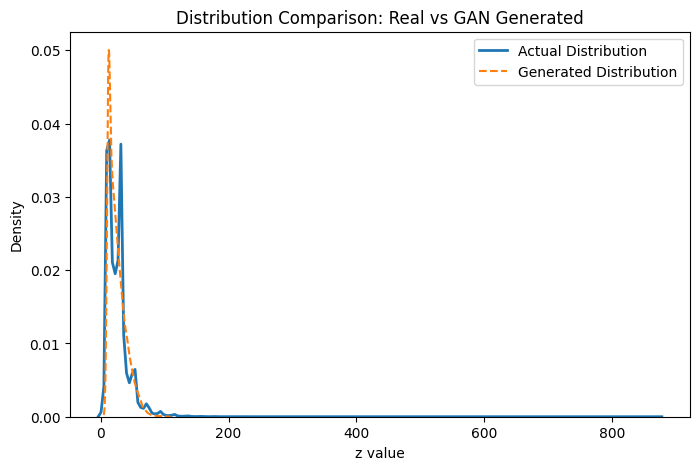

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/shrutibhargava94/india-air-quality-data/data.csv", encoding="latin1", low_memory=False)

no2_values = df["no2"].astype(float)
no2_values = no2_values.dropna().values

roll_number = 102316050
alpha = 0.5 * (roll_number % 7)
beta = 0.3 * ((roll_number % 5) + 1)

z_real = no2_values + alpha * np.sin(beta * no2_values)

z_tensor = torch.tensor(z_real, dtype=torch.float32).reshape(-1, 1)

class GenNet(nn.Module):
    def __init__(self, latent_dim=1):
        super(GenNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)


class DiscNet(nn.Module):
    def __init__(self):
        super(DiscNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


generator = GenNet()
discriminator = DiscNet()

loss_fn = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.001)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.001)

epochs = 2000
batch_size = 128

for epoch in range(epochs):

    indices = torch.randint(0, len(z_tensor), (batch_size,))
    real_samples = z_tensor[indices]

    noise = torch.randn(batch_size, 1)
    fake_samples = generator(noise)

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    output_real = discriminator(real_samples)
    output_fake = discriminator(fake_samples.detach())

    loss_real = loss_fn(output_real, real_labels)
    loss_fake = loss_fn(output_fake, fake_labels)

    d_loss = loss_real + loss_fake

    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    output_fake_for_G = discriminator(fake_samples)
    g_loss = loss_fn(output_fake_for_G, real_labels)

    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

with torch.no_grad():
    generated_data = generator(torch.randn(10000, 1)).numpy().flatten()

plt.figure(figsize=(8,5))
sns.kdeplot(z_real, label="Actual Distribution", linewidth=2)
sns.kdeplot(generated_data, label="Generated Distribution", linestyle="--")
plt.title("Distribution Comparison: Real vs GAN Generated")
plt.xlabel("z value")
plt.ylabel("Density")
plt.legend()
plt.show()
